# Predict-Then-Optimise Empirical Notebook

In [9]:
import json
import time
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn

ROOT = Path.cwd().resolve()
if not (ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv").exists() and (ROOT / "dfl_for_capital_allocation").is_dir():
    ROOT = ROOT / "dfl_for_capital_allocation"
while ROOT != ROOT.parent and not (ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv").exists():
    raise FileNotFoundError("Could not locate the project root containing empirical/data/processed/macro_panel_quarterly.csv")

import sys
sys.path.insert(0, str(ROOT))
from minou_colours import MINOU_COLOURS
from plotting_config import TEXT_WIDTH

FIGURES_DIR = ROOT / "empirical" / "figures" / "02_pto"
RESULTS_DIR = ROOT / "empirical" / "results" / "pto"
METADATA_PATH = ROOT / "empirical" / "data" / "processed" / "empirical_panel_metadata.json"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)

## Configuration
Decision and Basel constants (`LGD`, `M`, `K1`, `LEVERAGE`, `Y_BAR`, `LAMBDA`, the PD floor)
are defined and written to `empirical_panel_metadata.json` once the panel is
loaded to be used in `03_black_box_empirical` and `04_dfl_empirical` to ensure all models use the same decision environment. 

In [2]:
# Data conventions
CHARGE_OFF_IS_PERCENT = True
HORIZON = 1
DATE_COL = "DATE"
TARGET_COL = "charge_off_rate"
INCLUDE_CURRENT_CQ = True

# Decision and Basel constants
LGD = 0.45
M = 2.5
K1 = 1.0
LEVERAGE = 10.0
Y_BAR = 0.0168
LAMBDA = 10.0
RHO_SCALE = 0.03

# Basel corporate PD floor (0.03%)
APPLY_PD_FLOOR = True
PD_FLOOR = 3e-4

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99

# Allocation decisions are optimised continuously on [0, 1] with a bounded scalar solver
ALPHA_BOUNDS = (0.0, 1.0)
ALPHA_OPT_XATOL = 1e-10


# Expanding-window evaluation
FIRST_TEST_DATE = "2006-01-01"

## Quarterly PD, Basel IRB, and allocation objective

In [3]:
# Shared code, imported from the simulation pipeline's package 
SIMULATION_ROOT = ROOT / "simulation"
sys.path.insert(0, str(SIMULATION_ROOT))
from common import decision as dec
from common import model_config as mcfg
from common import pto_model
from common.decision import DecisionConfig
from empirical.common import data as emp_data
from empirical.common import model_config as empirical_mcfg

DCFG = DecisionConfig(
    LGD=LGD, K1=K1, ell=LEVERAGE, Y_BAR=Y_BAR, lambda_shortfall=LAMBDA, M=M, RHO_SCALE=RHO_SCALE,
    APPLY_PD_FLOOR=APPLY_PD_FLOOR, PD_FLOOR=PD_FLOOR,
    PD_Q_CLIP_LOW=PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH=PD_Q_CLIP_HIGH,
    PD_A_CLIP_LOW=PD_A_CLIP_LOW, PD_A_CLIP_HIGH=PD_A_CLIP_HIGH,
    ALPHA_BOUNDS=ALPHA_BOUNDS, ALPHA_OPT_XATOL=ALPHA_OPT_XATOL,
)

MODEL_CFG = empirical_mcfg.make_model_config(mcfg.ModelConfig)
MLP_SEEDS = empirical_mcfg.ENSEMBLE_SEEDS

def clip_pd_q(pd_q):
    return dec.clip_pd_q(pd_q, DCFG)


def clip_pd_a(pd_a):
    return dec.clip_pd_a(pd_a, DCFG)


def quarterly_pd_to_annual(pd_q):
    return dec.quarterly_pd_to_annual(pd_q, DCFG)


def k_irb_from_annual_pd(pd_a, lgd=None, m=None, apply_floor=None):
    return dec.k_irb_from_annual_pd(pd_a, DCFG, lgd=lgd, m=m, apply_floor=apply_floor)


def decision_components(alpha, c_q, pd_a):
    k = dec.k_irb_from_annual_pd(pd_a, DCFG)
    return dec.decision_components(alpha, c_q, k, DCFG)


def optimise_alpha_continuous(c_q, pd_a):
    k = dec.k_irb_from_annual_pd(pd_a, DCFG)
    return dec.optimise_alpha_oracle(c_q, k, DCFG)

## Load and align data

In [4]:
macro_csv = ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv"
df = emp_data.load_quarterly_pd_panel(
    macro_csv, dcfg=DCFG, date_col=DATE_COL, target_col=TARGET_COL, horizon=HORIZON,
    charge_off_is_percent=CHARGE_OFF_IS_PERCENT,
    include_current_cq=INCLUDE_CURRENT_CQ)
feature_cols = df.attrs["feature_cols"]

print(f"Observations after alignment and one-step target: {len(df)}")
n_before_first_test = int((df["target_date"] < pd.Timestamp(FIRST_TEST_DATE)).sum())
n_from_first_test = int((df["target_date"] >= pd.Timestamp(FIRST_TEST_DATE)).sum())
print(f"Evaluation split at {FIRST_TEST_DATE}: {n_before_first_test} training samples before, {n_from_first_test} samples from the first test date onward")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Target date range: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
assert "c_q_lag1" in feature_cols
assert ("c_q" in feature_cols) == INCLUDE_CURRENT_CQ
assert not any(col.startswith("pd_q") or col.startswith("pd_a") for col in feature_cols)
print(f"Lag features included: c_q_lag1{' and current-quarter c_q' if INCLUDE_CURRENT_CQ else ''}; PD columns excluded.")
display(df.head())

# Write decision/Basel constants to metadata JSON for 03_bb and 04_dfl
empirical_metadata = emp_data.write_panel_metadata(
    METADATA_PATH, DCFG, feature_cols=feature_cols, n_observations=len(df),
    date_range=[str(df[DATE_COL].min().date()), str(df[DATE_COL].max().date())],
    charge_off_is_percent=CHARGE_OFF_IS_PERCENT,
    include_current_cq=INCLUDE_CURRENT_CQ, pd_clip_low=PD_Q_CLIP_LOW, pd_clip_high=PD_Q_CLIP_HIGH)
print(f"Saved metadata")

Observations after alignment and one-step target: 142
Evaluation split at 2006-01-01: 61 training samples before, 81 samples from the first test date onward
Feature date range: 1990-07-01 to 2025-10-01
Target date range: 1990-10-01 to 2026-01-01
Features (14): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium', 'c_q_lag1', 'c_q']
Lag features included: c_q_lag1 and current-quarter c_q; PD columns excluded.


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,...,c_annual_decimal,c_q,pd_q,pd_a,target_date,c_annual_raw_next,c_q_realised,pd_q_realised,pd_a_realised,target_pd_q_next
0,1990-07-01,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,...,0.0128,0.003200,0.007111,0.028142,1990-10-01,1.30,0.003250,0.007222,0.028577,0.007222
1,1990-10-01,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,...,0.0130,0.003250,0.007222,0.028577,1991-01-01,1.48,0.003700,0.008222,0.032485,0.008222
2,1991-01-01,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,...,0.0148,0.003700,0.008222,0.032485,1991-04-01,1.86,0.004650,0.010333,0.040697,0.010333
3,1991-04-01,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,...,0.0186,0.004650,0.010333,0.040697,1991-07-01,1.97,0.004925,0.010944,0.043064,0.010944
4,1991-07-01,2.0,6.866667,1.390822,0.383417,0.759342,0.195457,5.643333,1.428906,16.634219,...,0.0197,0.004925,0.010944,0.043064,1991-10-01,1.83,0.004575,0.010167,0.040051,0.010167


Saved metadata


## Expanding-window evaluation 
See `simulation/pto_model.py` for more detailed implementation commentary.

In [5]:
def build_result_row(base_row, pd_q_hat, model_name, pd_q_hat_std=float("nan")):
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])

    alpha_hat, _ = optimise_alpha_continuous(c_q=c_q_hat, pd_a=pd_a_hat)
    alpha_oracle, utility_oracle = optimise_alpha_continuous(c_q=c_q_realised, pd_a=pd_a_realised)
    realised_components = decision_components(alpha_hat, c_q=c_q_realised, pd_a=pd_a_realised)
    oracle_components = decision_components(alpha_oracle, c_q=c_q_realised, pd_a=pd_a_realised)
    predicted_components = decision_components(alpha_hat, c_q=c_q_hat, pd_a=pd_a_hat)
    regret = utility_oracle - realised_components["utility"]

    return {"model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]), "c_annual_raw": float(base_row["c_annual_raw_next"]),
            "c_q_lag1": float(base_row["c_q_lag1"]),
            "c_q_realised": c_q_realised, "pd_q_realised": pd_q_realised, "pd_a_realised": pd_a_realised,
            "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std), "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat,
            "k_irb_realised": float(k_irb_from_annual_pd(pd_a_realised)), "k_irb_hat": float(k_irb_from_annual_pd(pd_a_hat)),
            "alpha_oracle": alpha_oracle, "alpha_hat": alpha_hat, "utility_oracle": utility_oracle,
            "utility": realised_components["utility"], "regret": regret,
            "shortfall_oracle": oracle_components["shortfall"],
            "shortfall_realised_at_hat": realised_components["shortfall"],
            "shortfall_predicted_at_hat": predicted_components["shortfall"]}


def resolve_first_test_idx(df, first_test_date):
    # Find first split point from supplied start date
    mask = (df["target_date"] >= pd.Timestamp(first_test_date)).to_numpy()
    if not mask.any():
        raise ValueError("first_test_date is after the last available target date.")
    first_test_idx = int(np.flatnonzero(mask)[0])
    if first_test_idx < 30 or len(df) - first_test_idx < 5:
        raise ValueError(f"Evaluation leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_pd_irb(df, feature_cols, first_test_date, model_cfg=MODEL_CFG,
                                return_history=True, stability_reference_X=None):
    first_test_idx = resolve_first_test_idx(df, first_test_date)
    total = len(df) - first_test_idx
    print(f"First test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {first_test_idx} initial training obs")
    records, histories = [], []
    stability_linear_rows, stability_mlp_rows = [], []
    t0 = time.time()

    # Loops over expanding window test dates
    for test_idx in range(first_test_idx, len(df)):
        train_df = df.iloc[:test_idx]
        test_row = df.iloc[test_idx]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
        y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        # Linear Specification
        linear_model, linear_hist = pto_model.train_pd_model(
            x_train, y_train, "linear", model_cfg, DCFG, return_history=True)
        records.append(build_result_row(
            test_row, float(pto_model.predict_pd_q(linear_model, x_test, DCFG)[0]), "linear"))

        # Optionally None to exclude running the stability analysis
        if stability_reference_X is not None:
            _x_ref_lin = scaler.transform(stability_reference_X)
            _ref_pred_lin = pto_model.predict_pd_q(linear_model, _x_ref_lin, DCFG)
            _ref_alpha_lin = []
            for _p in _ref_pred_lin:
                _p_clip = float(clip_pd_q(_p))
                _a_ref, _ = optimise_alpha_continuous(
                    c_q=float(LGD * _p_clip), pd_a=float(quarterly_pd_to_annual(_p_clip)))
                _ref_alpha_lin.append(_a_ref)
            _row_lin = {"refit_step": test_idx - first_test_idx,
                        "test_date": pd.to_datetime(test_row["target_date"]),
                        "train_end_date": pd.to_datetime(train_df[DATE_COL].iloc[-1]),
                        "n_train": len(train_df)}
            for _i, _p in enumerate(_ref_pred_lin):
                _row_lin[f"ref{_i}_pd_q_hat_mean"] = float(_p)
            for _i, _a in enumerate(_ref_alpha_lin):
                _row_lin[f"ref{_i}_alpha_hat_mean"] = float(_a)
            stability_linear_rows.append(_row_lin)

        # MLP Specification
        mlp_models, mlp_hist = pto_model.train_mlp_ensemble(
            x_train, y_train, model_cfg, DCFG, seeds=MLP_SEEDS, return_history=True)
        mlp_mean, mlp_std = pto_model.predict_pd_q_ensemble(mlp_models, x_test, DCFG)
        records.append(build_result_row(test_row, float(mlp_mean[0]), "mlp", pd_q_hat_std=float(mlp_std[0])))
       
        if stability_reference_X is not None:
            _x_ref = scaler.transform(stability_reference_X)
            _member_pd = np.stack([pto_model.predict_pd_q(m, _x_ref, DCFG) for m in mlp_models], axis=0)
            _ref_mean, _ref_std = _member_pd.mean(axis=0), _member_pd.std(axis=0)
            _ref_alpha_mlp = []
            for _m in _ref_mean:
                _m_clip = float(clip_pd_q(_m))
                _a_ref, _ = optimise_alpha_continuous(
                    c_q=float(LGD * _m_clip), pd_a=float(quarterly_pd_to_annual(_m_clip)))
                _ref_alpha_mlp.append(_a_ref)
            _row = {"refit_step": test_idx - first_test_idx,
                    "test_date": pd.to_datetime(test_row["target_date"]),
                    "train_end_date": pd.to_datetime(train_df[DATE_COL].iloc[-1]), "n_train": len(train_df)}
            for _i, (_m, _s) in enumerate(zip(_ref_mean, _ref_std)):
                _row[f"ref{_i}_pd_q_hat_mean"] = float(_m)
                _row[f"ref{_i}_pd_q_hat_std"] = float(_s)
                for _seed, _pred in zip(MLP_SEEDS, _member_pd[:, _i]):
                    _row[f"ref{_i}_pd_q_hat_seed{int(_seed)}"] = float(_pred)
                    _m_clip = float(clip_pd_q(_pred))
                    _a_seed, _ = optimise_alpha_continuous(c_q=float(LGD * _m_clip), pd_a=float(quarterly_pd_to_annual(_m_clip)))
                    _row[f"ref{_i}_alpha_hat_seed{int(_seed)}"] = float(_a_seed)
            for _i, _a in enumerate(_ref_alpha_mlp):
                _row[f"ref{_i}_alpha_hat_mean"] = float(_a)
            stability_mlp_rows.append(_row)

        # Persistence baseline: current-quarter implied PD carried forward
        records.append(build_result_row(test_row, float(clip_pd_q(test_row["c_q"] / LGD)), "persistence"))

        if return_history:
            for hist in (linear_hist, mlp_hist):
                if hist is not None:
                    hist = hist.copy()
                    hist["test_date"] = pd.to_datetime(test_row["target_date"])
                    hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                    histories.append(hist)

        done = test_idx - first_test_idx + 1
        # Progress report
        if done % 5 == 0 or test_idx == len(df) - 1:
            print(f"Completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
            
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    stability_linear = pd.DataFrame(stability_linear_rows)
    stability_mlp = pd.DataFrame(stability_mlp_rows)
    return pred_long, history, stability_linear, stability_mlp

# Uses all available points as stability reference points
STABILITY_REF_X, STABILITY_REF_DATES = df[feature_cols].to_numpy(dtype=float), df[DATE_COL].to_numpy()

pl, th, sl, sm = run_expanding_window_pd_irb(
    df, feature_cols, FIRST_TEST_DATE, stability_reference_X=STABILITY_REF_X)
pred_long, training_history, stability_linear, stability_mlp = pl, th, sl, sm
display(pred_long.head())

First test target: 2006-01-01, 81 windows, 61 initial training obs
Completed 5/81 windows (25s elapsed)
Completed 10/81 windows (41s elapsed)
Completed 15/81 windows (53s elapsed)
Completed 20/81 windows (62s elapsed)
Completed 25/81 windows (74s elapsed)
Completed 30/81 windows (92s elapsed)
Completed 35/81 windows (110s elapsed)
Completed 40/81 windows (144s elapsed)
Completed 45/81 windows (183s elapsed)
Completed 50/81 windows (226s elapsed)
Completed 55/81 windows (266s elapsed)
Completed 60/81 windows (296s elapsed)
Completed 65/81 windows (316s elapsed)
Completed 70/81 windows (338s elapsed)
Completed 75/81 windows (362s elapsed)
Completed 80/81 windows (384s elapsed)
Completed 81/81 windows (390s elapsed)


,model,date,feature_date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,pd_q_hat,pd_q_hat_std,...,k_irb_realised,k_irb_hat,alpha_oracle,alpha_hat,utility_oracle,utility,regret,shortfall_oracle,shortfall_realised_at_hat,shortfall_predicted_at_hat
0,linear,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.001789,NaN,...,0.053913,0.064907,0.726543,0.671539,1.118245,1.109293,0.008952,0.0,0.0,0.0
1,mlp,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.001868,0.000205,...,0.053913,0.066054,0.726543,0.666245,1.118245,1.108431,0.009813,0.0,0.0,0.0
2,persistence,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.001722,NaN,...,0.053913,0.063911,0.726543,0.676197,1.118245,1.110051,0.008194,0.0,0.0,0.0
3,linear,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,0.001786,NaN,...,0.060307,0.064873,0.693570,0.671694,1.111838,1.108311,0.003528,0.0,0.0,0.0
4,mlp,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,0.001603,0.000153,...,0.060307,0.062033,0.693570,0.685144,1.111838,1.110480,0.001359,0.0,0.0,0.0


## Result collection

In [6]:
base_cols = ["date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised",
             "k_irb_realised", "alpha_oracle", "utility_oracle"]
metric_cols = ["pd_q_hat", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "utility", "regret"]
MODEL_ORDER = ["linear", "mlp", "persistence"]

def make_wide_results(pred_long):
    sub = pred_long
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results = make_wide_results(pred_long)
output_csv = RESULTS_DIR / "pto_quarterly_pd_irb_predictions.csv"
results.to_csv(output_csv, index=False)
print(f"Saved {len(results)} rows to {output_csv.relative_to(ROOT)}")
lin_sub = stability_linear
mlp_sub = stability_mlp
lin_csv = RESULTS_DIR / "pto_stability_linear_reference_outputs.csv"
mlp_csv = RESULTS_DIR / "pto_stability_mlp_reference_outputs.csv"
lin_sub.to_csv(lin_csv, index=False)
mlp_sub.to_csv(mlp_csv, index=False)
print(f"Saved {len(lin_sub)} linear reference-output rows to {lin_csv.relative_to(ROOT)}")
print(f"Saved {len(mlp_sub)} MLP reference-output rows to {mlp_csv.relative_to(ROOT)}")
display(results.head())

Saved 81 rows to empirical/results/pto/pto_quarterly_pd_irb_predictions.csv
Saved 81 linear reference-output rows to empirical/results/pto/pto_stability_linear_reference_outputs.csv
Saved 81 MLP reference-output rows to empirical/results/pto/pto_stability_mlp_reference_outputs.csv


,date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,utility_oracle,pd_q_hat_linear,...,k_irb_hat_persistence,alpha_hat_linear,alpha_hat_mlp,alpha_hat_persistence,utility_linear,utility_mlp,utility_persistence,regret_linear,regret_mlp,regret_persistence
0,2006-01-01,0.21,0.000525,0.000525,0.001167,0.004659,0.053913,0.726543,1.118245,0.001789,...,0.063911,0.671539,0.666245,0.676197,1.109293,1.108431,1.110051,0.008952,0.009813,0.008194
1,2006-04-01,0.27,0.000775,0.000675,0.001500,0.005987,0.060307,0.693570,1.111838,0.001786,...,0.053913,0.671694,0.685144,0.726543,1.108311,1.110480,0.641744,0.003528,0.001359,0.470094
2,2006-07-01,0.30,0.000525,0.000750,0.001667,0.006650,0.063051,0.680266,1.109183,0.001544,...,0.060307,0.689848,0.701738,0.693570,0.969856,0.796980,0.915742,0.139327,0.312202,0.193440
3,2006-10-01,0.34,0.000675,0.000850,0.001889,0.007534,0.066343,0.664926,1.106056,0.001679,...,0.063051,0.679379,0.694787,0.680266,0.890999,0.661733,0.877802,0.215056,0.444323,0.228254
4,2007-01-01,0.37,0.000750,0.000925,0.002056,0.008197,0.068577,0.654869,1.103960,0.002216,...,0.066343,0.646170,0.650147,0.664926,1.102580,1.103211,0.951990,0.001381,0.000750,0.151970


## Diagnostics and sanity checks

In [7]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"Charge-off input is percent-scaled; simple x4 annualisation inverted; "
      f"PD floor applied: {APPLY_PD_FLOOR} ({PD_FLOOR:.2%}); MLP seeds: {MLP_SEEDS}")
print(f"Loss: Vasicek NLL; RHO_SCALE: {RHO_SCALE}")

assert np.allclose(pred_long["pd_q_realised"], clip_pd_q(pred_long["c_q_realised"] / LGD))
for col in ["pd_q_realised", "pd_q_hat", "pd_a_realised", "pd_a_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
for col in ["k_irb_realised", "k_irb_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals >= 0.0).all(), col

assert np.allclose(pred_long["pd_a_realised"], quarterly_pd_to_annual(pred_long["pd_q_realised"]), atol=1e-12)
assert np.allclose(pred_long["pd_a_hat"], quarterly_pd_to_annual(pred_long["pd_q_hat"]), atol=1e-12)
assert np.allclose(pred_long["k_irb_hat"], k_irb_from_annual_pd(pred_long["pd_a_hat"].to_numpy()), atol=1e-12)
print("IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.")

min_regret = pred_long["regret"].min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative regret found: {min_regret}")
print(f"Minimum regret across models: {min_regret:.3e}")

summary_cols = (["c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised"]
                + [f"pd_q_hat_{m}" for m in MODEL_ORDER]
                + ["pd_a_realised"] + [f"pd_a_hat_{m}" for m in MODEL_ORDER]
                + ["k_irb_realised"] + [f"k_irb_hat_{m}" for m in MODEL_ORDER]
                + ["alpha_oracle"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER])
print("=== Evaluation summary ===")
display(describe_columns(results, summary_cols))

shortfall_summary = pred_long.groupby(["model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

mlp_std = pred_long[pred_long["model"] == "mlp"]["pd_q_hat_std"].describe()
print("Cross-seed std of MLP ensemble predictions:")
display(mlp_std)

Charge-off input is percent-scaled; simple x4 annualisation inverted; PD floor applied: True (0.03%); MLP seeds: (42, 43, 44, 45, 46)
Loss: Vasicek NLL; RHO_SCALE: 0.03
IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.
Minimum regret across models: 0.000e+00
=== Evaluation summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,81.0,0.578025,0.540653,1.200000e-01,0.160000,0.270000,0.410000,0.570000,1.940000,2.570000
c_q_lag1,81.0,0.001426,0.001357,3.000000e-04,0.000400,0.000675,0.000925,0.001400,0.004850,0.006425
c_q_realised,81.0,0.001445,0.001352,3.000000e-04,0.000400,0.000675,0.001025,0.001425,0.004850,0.006425
pd_q_realised,81.0,0.003211,0.003004,6.666667e-04,0.000889,0.001500,0.002278,0.003167,0.010778,0.014278
pd_q_hat_linear,81.0,0.004650,0.005764,1.338153e-03,0.001568,0.001928,0.002469,0.003179,0.017329,0.026093
pd_q_hat_mlp,81.0,0.003853,0.002941,1.154910e-03,0.001363,0.002140,0.002844,0.004235,0.010236,0.014685
pd_q_hat_persistence,81.0,0.003192,0.003008,6.666667e-04,0.000889,0.001500,0.002167,0.003111,0.010778,0.014278
pd_a_realised,81.0,0.012730,0.011780,2.664001e-03,0.003551,0.005987,0.009080,0.012607,0.042419,0.055900
pd_a_hat_linear,81.0,0.018277,0.022233,5.341879e-03,0.006258,0.007689,0.009841,0.012657,0.067536,0.100357
pd_a_hat_mlp,81.0,0.015273,0.011531,4.611643e-03,0.005440,0.008534,0.011328,0.016831,0.040319,0.057457


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                                 mean       max bind_share   
model                                                        
linear                       0.007969  0.100653   0.259259   
mlp                          0.011132  0.154527   0.283951   
persistence                  0.014488  0.079900   0.518519   

            shortfall_predicted_at_hat                           
                                  mean           max bind_share  
model                                                            
linear                    1.246544e-12  1.009701e-10   0.012346  
mlp                       0.000000e+00  0.000000e+00   0.000000  
persistence               0.000000e+00  0.000000e+00   0.000000

Cross-seed std of MLP ensemble predictions:


count    81.000000
mean      0.000738
std       0.000874
min       0.000093
25%       0.000299
50%       0.000490
75%       0.000784
max       0.005250
Name: pd_q_hat_std, dtype: float64

## Plots

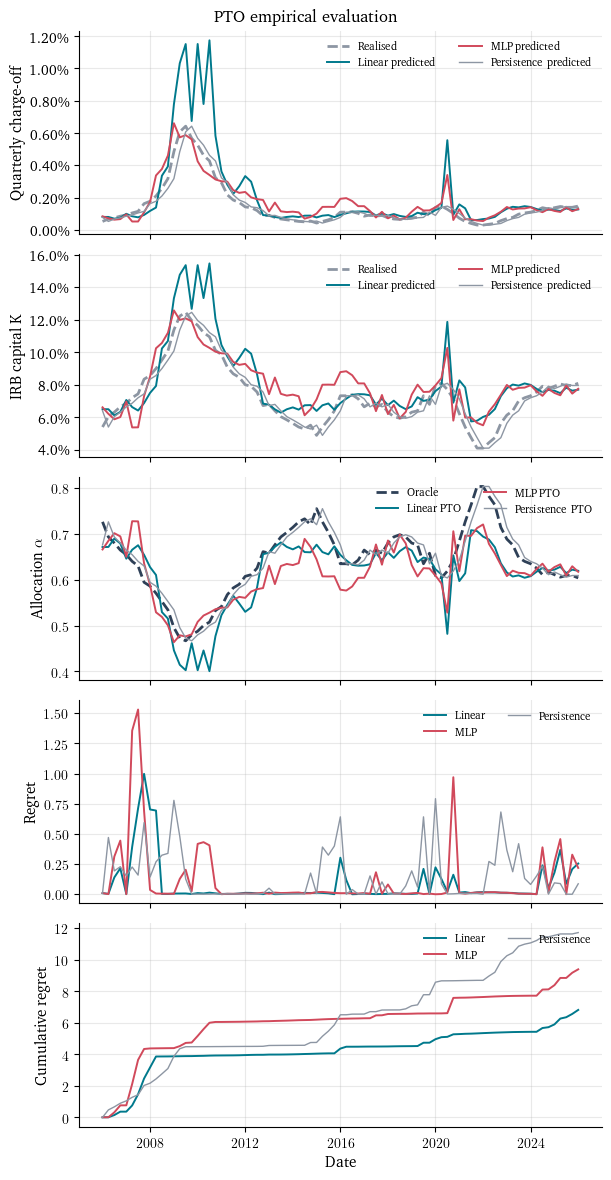

In [14]:
MODEL_COLORS = {"linear": MINOU_COLOURS["teal"], "mlp": MINOU_COLOURS["coral"], "persistence": MINOU_COLOURS["grey"]}
MODEL_LW = {"linear": 1.4, "mlp": 1.4, "persistence": 1.0}
MODEL_LABELS = {"linear": "Linear", "mlp": "MLP", "persistence": "Persistence"}
ORACLE_COLOR = MINOU_COLOURS["navy"]
REAL_COLOR = MINOU_COLOURS["grey"]

def format_date_axis(ax, year_step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(year_step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix=""):
    for m in MODEL_ORDER:
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_results(res):
    fig_dir = FIGURES_DIR
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()
    year_step = 2 if len(plot_df) <= 60 else 4
    fig, axes = plt.subplots(5, 1, figsize=(TEXT_WIDTH, 12), sharex=True)
    fig.subplots_adjust(hspace=0.12)

    axes[0].plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[0], plot_df, "c_q_hat", " predicted")
    axes[0].set_ylabel("Quarterly charge-off"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

    axes[1].plot(plot_df["date"], plot_df["k_irb_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[1], plot_df, "k_irb_hat", " predicted")
    axes[1].set_ylabel("IRB capital K"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(axes[2], plot_df, "alpha_hat", " PTO")
    axes[2].set_ylabel(r"Allocation $\alpha$")

    for m in MODEL_ORDER:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[4].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret")
    axes[4].set_ylabel("Cumulative regret"); axes[4].set_xlabel("Date")

    for ax in axes:
        format_date_axis(ax, year_step); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=2)
    fig.suptitle("PTO empirical evaluation")
    plt.tight_layout(); plt.savefig(fig_dir / "pto_empirical_summary_panel.pdf", dpi=300, bbox_inches="tight"); plt.show()
    return

plot_results(results)

## Learning curves

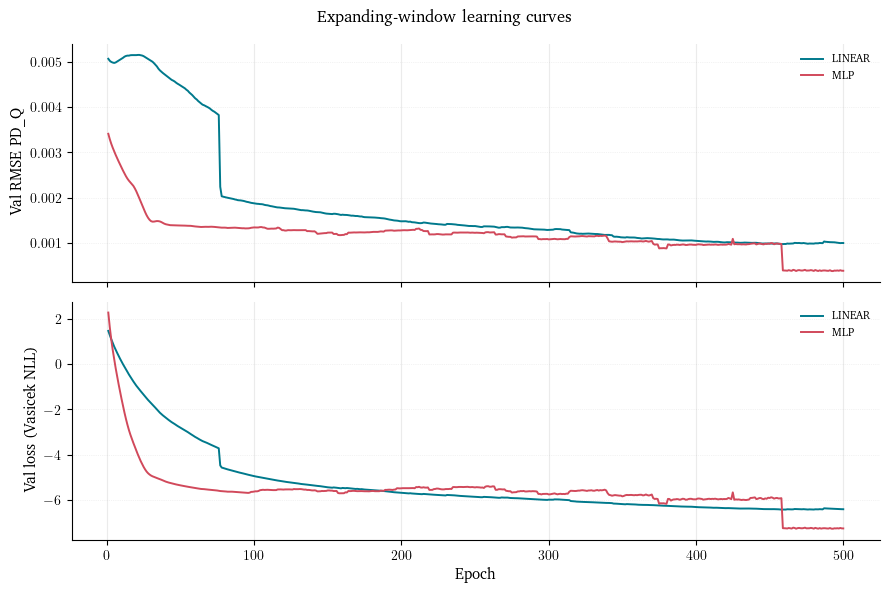

In [15]:
if not training_history.empty:
    for split_hist in [training_history]:
        mean_history = split_hist.groupby(["model", "epoch"], as_index=False).agg(
            mean_val_rmse_pd_q=("val_rmse_pd_q", "mean"), mean_val_loss=("val_loss", "mean"))
        fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            axes[0].plot(group["epoch"], group["mean_val_rmse_pd_q"], color=color, lw=1.4, label=model_name.upper())
            axes[1].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=model_name.upper())
        axes[0].set_ylabel("Val RMSE PD_Q")
        axes[1].set_ylabel("Val loss (Vasicek NLL)"); axes[1].set_xlabel("Epoch")
        for ax in axes:
            ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves"); plt.tight_layout()
        fig_dir = FIGURES_DIR
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.pdf", dpi=200, bbox_inches="tight"); plt.show()